# **PRCP-1000-PortugeseBank**

NAME : HEMALATHA R

# **Domain: Finance/Banking**

dataset : content/bank-additional-full.csv


# Problem Statement

Task 1: complete data analysis report on the given data.

Task 2: Model to predict which customer will buy a product

Task3: Bank market team to make  customers  buy the product.


# **Summary**
The Bank Marketing Campaign Prediction project aims to help banks identify customers who are more likely to subscribe to term deposits, improving campaign efficiency and reducing marketing costs. Using a dataset containing customer information such as age, job, balance, previous marketing interactions, and communication details, I performed extensive data preprocessing, including handling categorical features, converting binary variables to boolean, and applying one-hot encoding.

I addressed key challenges such as class imbalance by using threshold tuning and carefully selecting evaluation metrics like F1-score and recall to ensure accurate prediction of minority class subscribers. Feature selection and correlation analysis were also performed to reduce redundancy and improve model performance.

The project demonstrates the application of machine learning to real-world marketing problems, enabling banks to focus efforts on high-probability customers and make data-driven decisions.

# **BLOCK-1**
**1.1.IMPORT LIBRAIES**

In [1]:
# == core libraries ==
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# == visualization ==
import seaborn as sns
import matplotlib.pyplot as plt

**1.2. LOADING DATASET**


In [2]:
# == read the file ==
df  = pd.read_csv("/content/bank-additional-full.csv", sep =";")

**1.3. BASIC OVERVIEW**

In [3]:
# == first five rows ==
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
# == information of the dataset ==
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [5]:
# == summary of the dataset ==
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [6]:
# == number of rows and columns ==
df.shape

(41188, 21)

In [7]:
# == dtypes ==
df.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
housing,object
loan,object
contact,object
month,object
day_of_week,object


In [8]:
# == count of data types ==
df.dtypes.value_counts()

,count
object,11
int64,5
float64,5


**1.4. CHECKING MISSING VALUES**

In [9]:
# == Check for missing values ==
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [10]:
df.nunique()

,0
age,78
job,12
marital,4
education,8
default,3
housing,3
loan,3
contact,2
month,10
day_of_week,5


In [11]:
# == column names ==
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')


# EDA

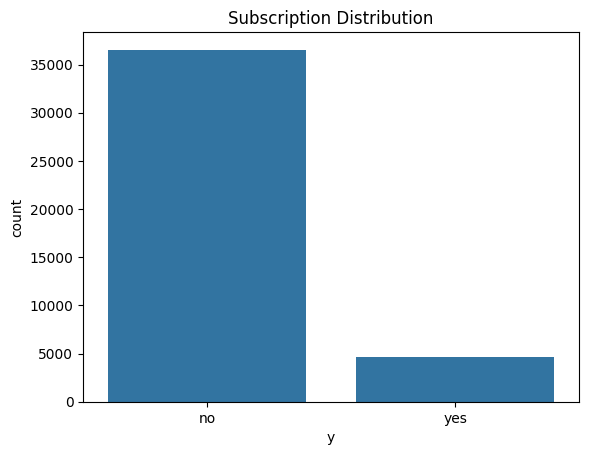

In [12]:
# Most customers did not subscribe to the bank’s product, showing a low conversion rate. Targeted marketing could help improve subscriptions
sns.countplot(x='y', data=df)
plt.title("Subscription Distribution")
plt.show()

In [13]:
df['y'].value_counts(normalize=True)*100

,proportion
y,
no,88.734583
yes,11.265417


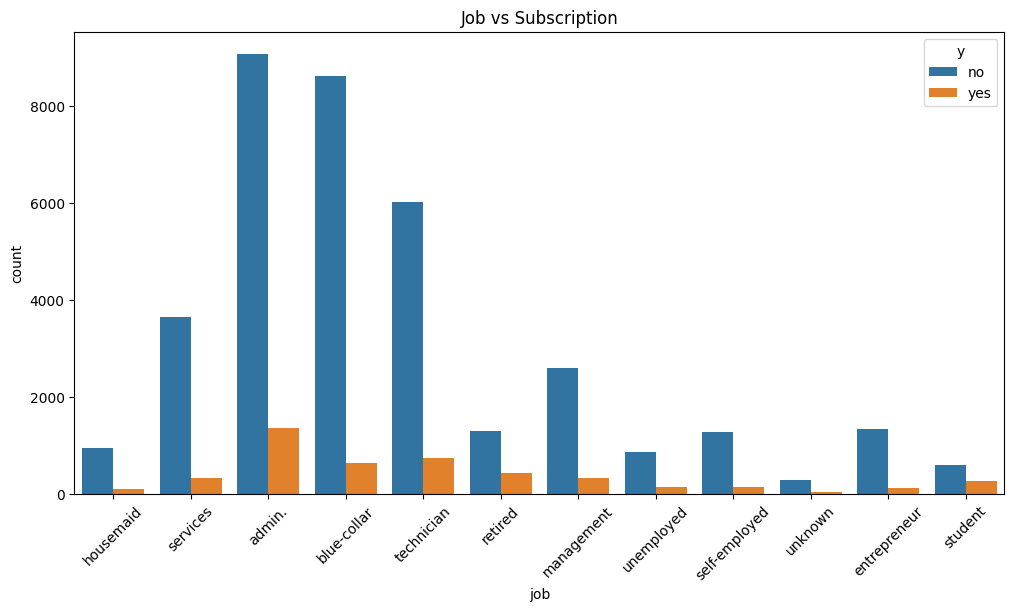

In [14]:

# The subscription rates vary by job type. Some jobs, like [insert top jobs from your graph], show higher subscriptions,
# while others have mostly non-subscribers. This indicates that occupation influences the likelihood of subscribing,
# so marketing campaigns can be tailored to target job groups more likely to subscribe.
plt.figure(figsize=(12,6))
sns.countplot(x='job', hue='y', data=df)
plt.xticks(rotation=45)
plt.title("Job vs Subscription")
plt.show()


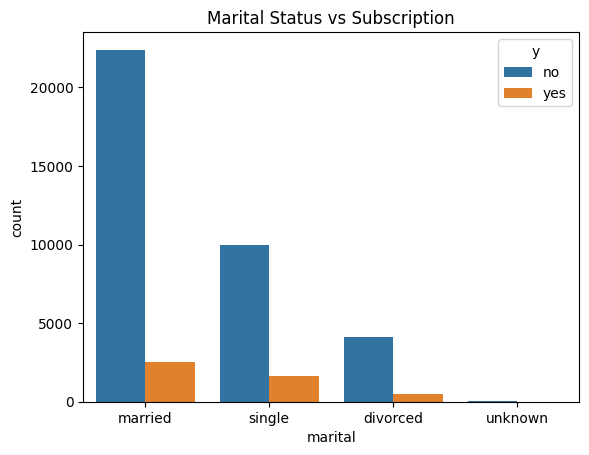

In [15]:

# Subscription rates differ by marital status. Married customers tend to subscribe more than single
# or divorced ones, suggesting that marital status may influence a customer’s likelihood to invest in the bank’s product.
sns.countplot(x='marital', hue='y', data=df)
plt.title("Marital Status vs Subscription")
plt.show()

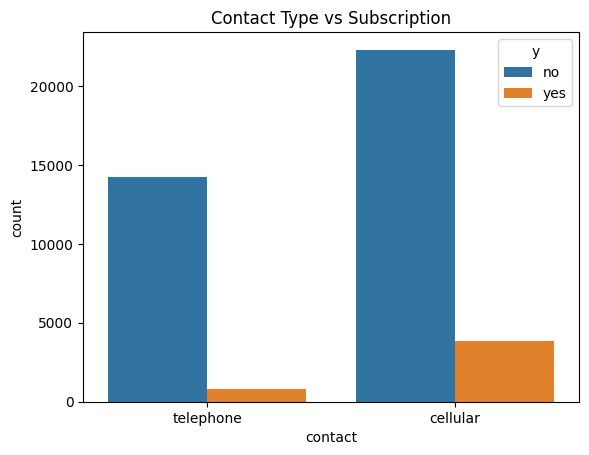

In [16]:
# Customers contacted via cellular show higher subscription rates compared to those contacted by telephone,
# indicating that mobile outreach is more effective for product subscriptions.
sns.countplot(x='contact', hue='y', data=df)
plt.title("Contact Type vs Subscription")
plt.show()

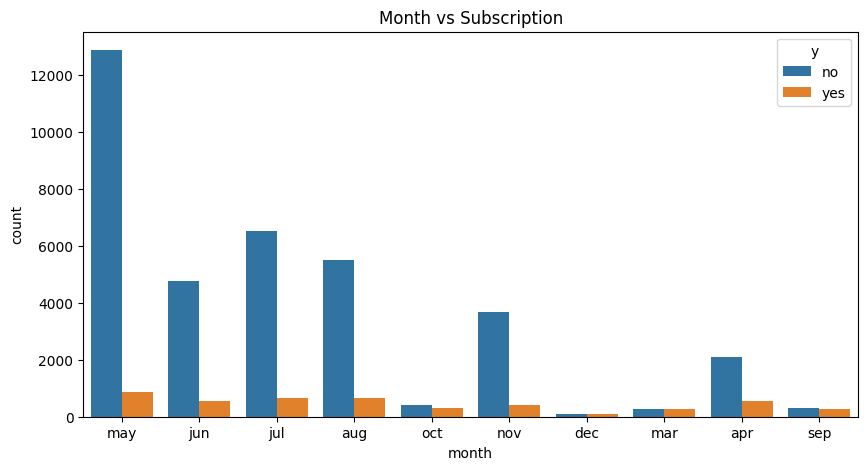

In [17]:
# Subscription rates vary across months. Certain months show higher subscriptions,
# suggesting that the timing of marketing campaigns can influence customer response and effectiveness.
plt.figure(figsize=(10,5))
sns.countplot(x='month', hue='y', data=df)
plt.title("Month vs Subscription")
plt.show()

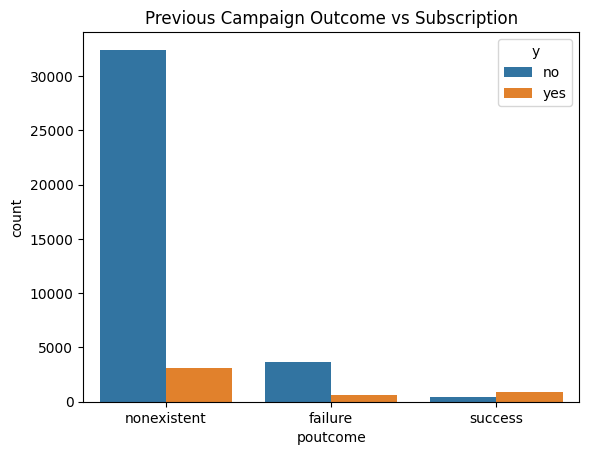

In [18]:
# Customers with a successful previous campaign outcome are much more likely to subscribe,
# while those with failure or no prior contact show lower subscriptions.
# This highlights the importance of past campaign results in predicting customer response.
sns.countplot(x='poutcome', hue='y', data=df)
plt.title("Previous Campaign Outcome vs Subscription")
plt.show()

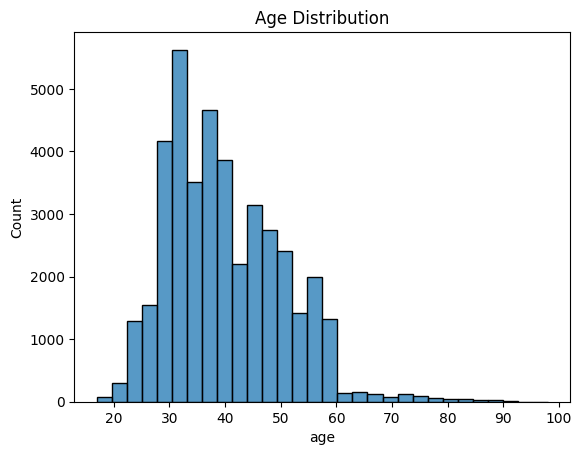

In [19]:
# Most customers are in the [insert dominant age range from your graph] age group,
# indicating that the bank’s services mainly attract middle-aged adults.
# Age could be an important factor in targeting marketing campaigns.
df['age'] = pd.to_numeric(df['age'], errors='coerce')
sns.histplot(df['age'].dropna(), bins=30)
plt.title("Age Distribution")
plt.show()

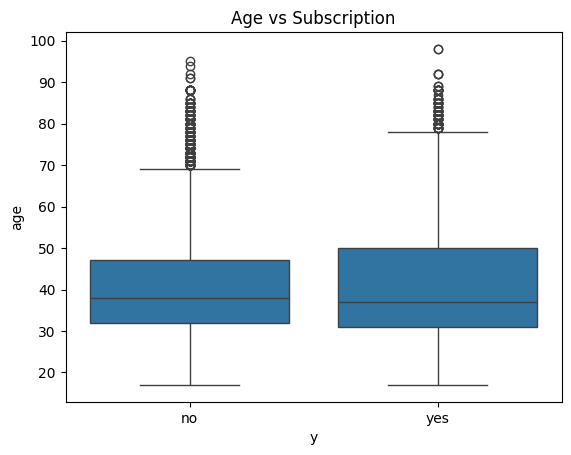

In [20]:
# Customers who subscribe (yes) tend to be slightly older than non-subscribers (no),
#  suggesting that age may influence the likelihood of subscribing to the bank’s product.
sns.boxplot(x='y', y='age', data=df)
plt.title("Age vs Subscription")
plt.show()

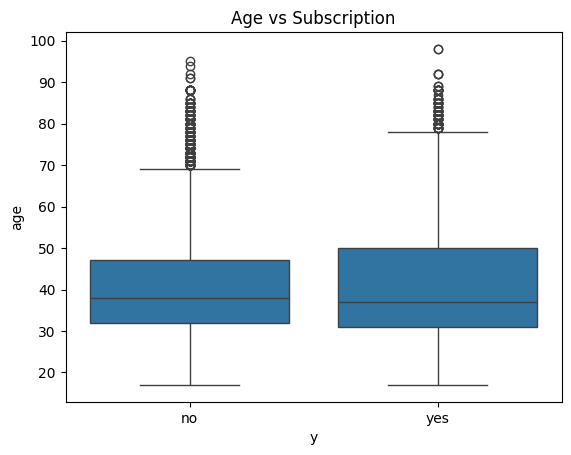

In [21]:
# Customers who subscribe (yes) tend to be slightly older than non-subscribers (no),
#  suggesting that age may influence the likelihood of subscribing to the bank’s product.
sns.boxplot(x='y', y='age', data=df)
plt.title("Age vs Subscription")
plt.show()

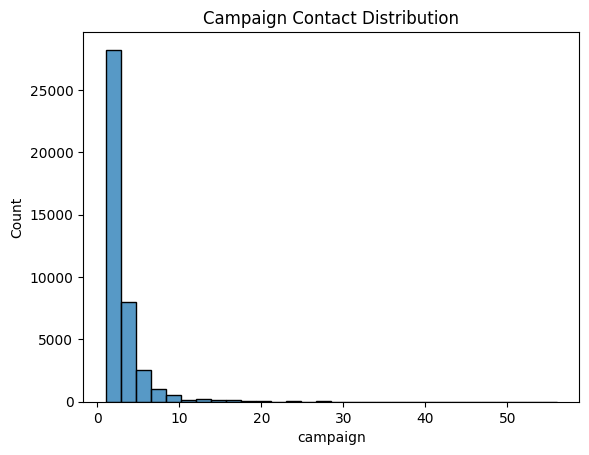

In [22]:
# Most customers were contacted a few times, while very few were contacted many times.
# This suggests that excessive contact is rare and that targeting efficiency may vary with the number of contacts.
sns.histplot(df['campaign'], bins=30)
plt.title("Campaign Contact Distribution")
plt.show()

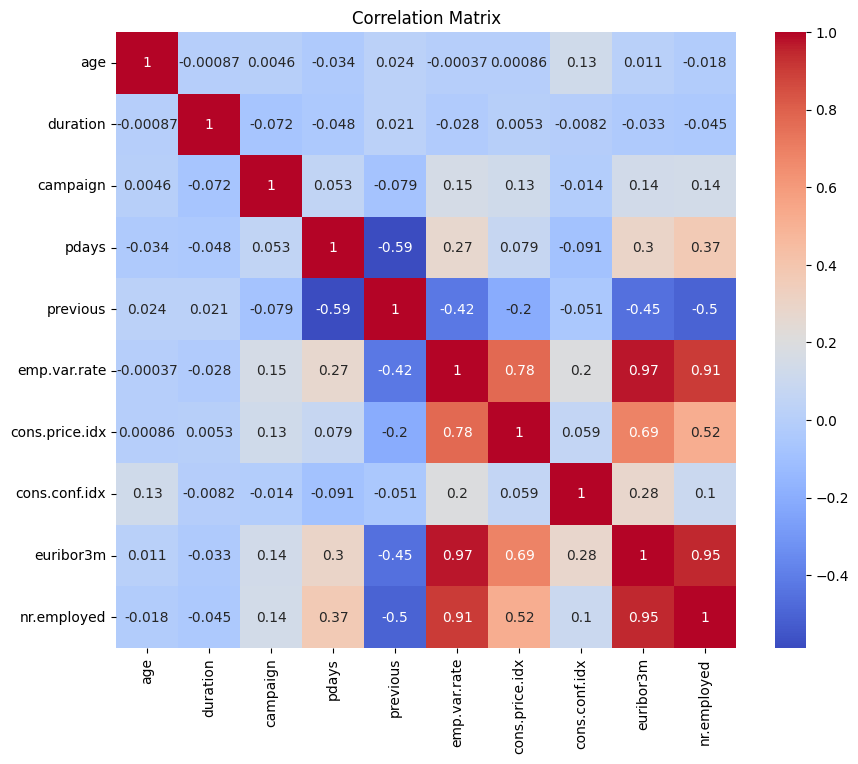

In [23]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

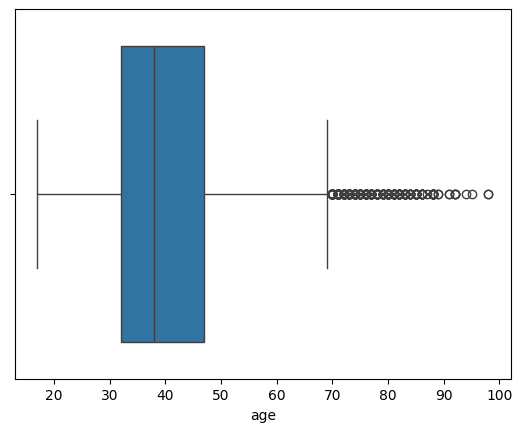

In [24]:
sns.boxplot(x=df['age'])
plt.show()

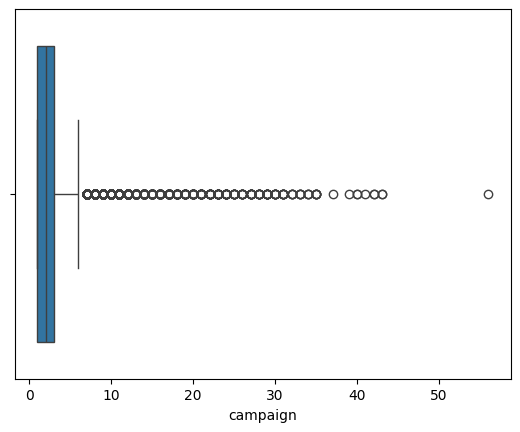

In [25]:
sns.boxplot(x=df['campaign'])
plt.show()

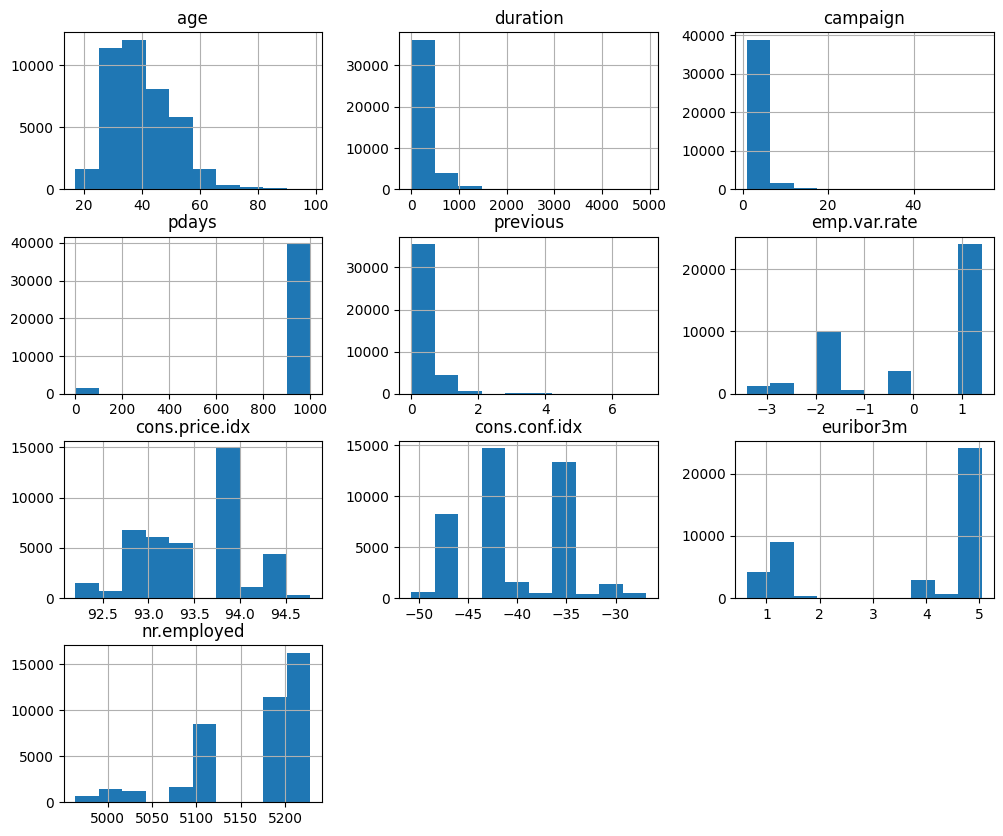

In [26]:
# The histograms show the distribution of all numerical features.
# Most features are skewed, with some having outliers, indicating that data preprocessing (like scaling or outlier handling) may be needed before modeling.
df.hist(figsize=(12,10))
plt.show()

# **DATA PREPROCESSING**

In [27]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

le = LabelEncoder()

# Step 1: Label Encoding
binary_cols = ['default', 'housing', 'loan', 'y']
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# Step 2: One-Hot Encoding
df = pd.get_dummies(df,
                      columns=['job', 'marital', 'education', 'contact', 'month', 'poutcome'],
                      drop_first=True)

print(df.dtypes)

age                                int64
default                            int64
housing                            int64
loan                               int64
day_of_week                       object
duration                           int64
campaign                           int64
pdays                              int64
previous                           int64
emp.var.rate                     float64
cons.price.idx                   float64
cons.conf.idx                    float64
euribor3m                        float64
nr.employed                      float64
y                                  int64
job_blue-collar                     bool
job_entrepreneur                    bool
job_housemaid                       bool
job_management                      bool
job_retired                         bool
job_self-employed                   bool
job_services                        bool
job_student                         bool
job_technician                      bool
job_unemployed  

# **CORRELATION**

In [28]:
df.corr(numeric_only=True)

,age,default,housing,loan,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,...,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_nonexistent,poutcome_success
age,1.000000,0.164965,-0.001603,-0.007368,-0.000866,0.004594,-0.034369,0.024365,-0.000371,0.000857,...,0.046563,-0.043563,-0.009532,0.008390,-0.067523,0.030045,0.053008,0.040889,-0.016376,0.035626
default,0.164965,1.000000,-0.015815,-0.003782,-0.011794,0.032825,0.080062,-0.102416,0.203263,0.168073,...,-0.028816,0.037551,0.050067,-0.051178,0.066952,-0.085652,-0.060199,-0.054710,0.103948,-0.075754
housing,-0.001603,-0.015815,1.000000,0.044296,-0.007658,-0.011010,-0.010551,0.021314,-0.060196,-0.080504,...,0.007039,-0.000878,-0.054996,0.013108,-0.022383,0.032332,0.003108,0.006986,-0.025157,0.012152
loan,-0.007368,-0.003782,0.044296,1.000000,-0.000916,0.005166,0.000345,-0.001327,0.001849,-0.002430,...,0.007289,0.013629,-0.004828,-0.004334,0.001684,-0.006138,-0.008996,-0.001905,-0.000120,-0.001412
duration,-0.000866,-0.011794,-0.007658,-0.000916,1.000000,-0.071699,-0.047577,0.020640,-0.027968,0.005312,...,0.022438,0.026819,-0.023351,-0.005516,0.008054,-0.015941,0.015454,0.018011,-0.011665,0.044876
campaign,0.004594,0.032825,-0.011010,0.005166,-0.071699,1.000000,0.052584,-0.079141,0.150754,0.127836,...,-0.009819,0.098385,0.070144,-0.015244,-0.032704,-0.079028,-0.049126,-0.033953,0.087645,-0.050893
pdays,-0.034369,0.080062,-0.010551,0.000345,-0.047577,0.052584,1.000000,-0.587514,0.271004,0.078889,...,-0.076425,0.049695,0.015957,-0.078769,0.070690,-0.016946,-0.128677,-0.154629,0.491353,-0.950700
previous,0.024365,-0.102416,0.021314,-0.001327,0.020640,-0.079141,-0.587514,1.000000,-0.420489,-0.203130,...,0.059557,-0.116785,-0.069905,0.072733,-0.012534,0.081050,0.127754,0.157651,-0.878776,0.524045
emp.var.rate,-0.000371,0.203263,-0.060196,0.001849,-0.027968,0.150754,0.271004,-0.420489,1.000000,0.775334,...,-0.124174,0.314863,0.148653,-0.138849,-0.111356,-0.105917,-0.213706,-0.170366,0.472501,-0.256886
cons.price.idx,0.000857,0.168073,-0.080504,-0.002430,0.005312,0.127836,0.078889,-0.203130,0.775334,1.000000,...,-0.099017,0.253303,0.445513,-0.095783,-0.057274,-0.215273,-0.092174,-0.046905,0.304264,-0.077416


In [30]:
res=df.corr(numeric_only=True)

In [31]:
res[res>0.8]

,age,default,housing,loan,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,...,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_nonexistent,poutcome_success
age,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
housing,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
campaign,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pdays,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
previous,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
emp.var.rate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cons.price.idx,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
df.isna().sum()

,0
age,0
default,0
housing,0
loan,0
day_of_week,0
duration,0
campaign,0
pdays,0
previous,0
emp.var.rate,0


In [ ]:
df.duplicated().sum()

np.int64(12)

In [33]:
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

In [34]:
df.columns

Index(['age', 'default', 'housing', 'loan', 'day_of_week', 'duration',
       'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y', 'job_blue-collar',
       'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired',
       'job_self-employed', 'job_services', 'job_student', 'job_technician',
       'job_unemployed', 'job_unknown', 'marital_married', 'marital_single',
       'marital_unknown', 'education_basic.6y', 'education_basic.9y',
       'education_high.school', 'education_illiterate',
       'education_professional.course', 'education_university.degree',
       'education_unknown', 'contact_telephone', 'month_aug', 'month_dec',
       'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov',
       'month_oct', 'month_sep', 'poutcome_nonexistent', 'poutcome_success'],
      dtype='object')

In [35]:
df.dtypes

,0
age,int64
default,int64
housing,int64
loan,int64
day_of_week,object
duration,int64
campaign,int64
pdays,int64
previous,int64
emp.var.rate,float64


In [36]:
X = df.drop(['y','duration'], axis=1)
y = df['y']

# **OUTLIER**

In [37]:
# Create new feature
df['previously_contacted'] = df['pdays'].apply(lambda x: 0 if x == 999 else 1)

# Fix pdays
df['pdays'] = df['pdays'].apply(lambda x: 0 if x == 999 else x)

In [38]:
num_cols = ['age','campaign','pdays','previous']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, "Outliers:", len(outliers))

age Outliers: 469
campaign Outliers: 2406
pdays Outliers: 1500
previous Outliers: 5625


In [39]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] > upper, upper,
                np.where(df[col] < lower, lower, df[col]))


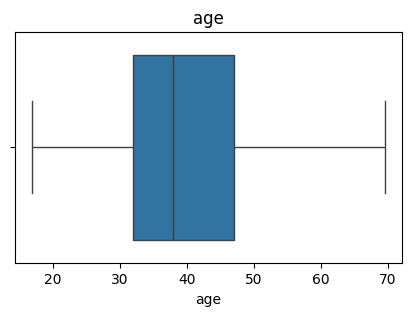

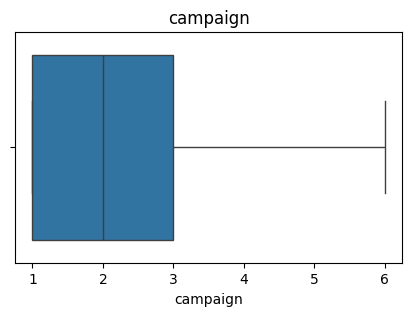

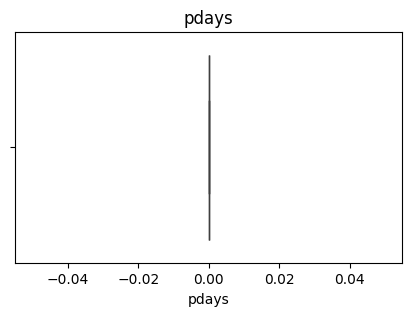

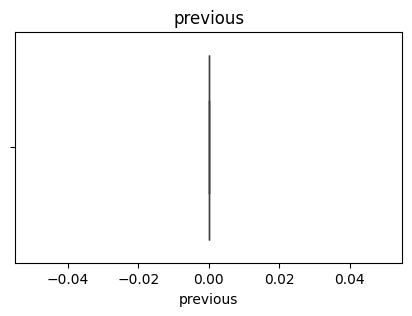

In [40]:
num_cols = ['age','campaign','pdays','previous']

for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

# **SCALING**

In [41]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

num_cols = ['age','campaign','pdays','previous']

df[num_cols] = scaler.fit_transform(df[num_cols])

print(df.head())

        age  default  housing  loan day_of_week  duration  campaign  pdays  \
0  1.200000        0        0     0         mon       261      -0.5    0.0   
1  1.266667        1        0     0         mon       149      -0.5    0.0   
2 -0.066667        0        2     0         mon       226      -0.5    0.0   
3  0.133333        0        0     0         mon       151      -0.5    0.0   
4  1.200000        0        0     2         mon       307      -0.5    0.0   

   previous  emp.var.rate  ...  month_jul  month_jun  month_mar  month_may  \
0       0.0           1.1  ...          0          0          0          1   
1       0.0           1.1  ...          0          0          0          1   
2       0.0           1.1  ...          0          0          0          1   
3       0.0           1.1  ...          0          0          0          1   
4       0.0           1.1  ...          0          0          0          1   

   month_nov  month_oct  month_sep  poutcome_nonexistent  pout

In [42]:
X.head(2)

,age,default,housing,loan,day_of_week,campaign,pdays,previous,emp.var.rate,cons.price.idx,...,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_nonexistent,poutcome_success
0,56,0,0,0,mon,1,999,0,1.1,93.994,...,0,0,0,0,1,0,0,0,1,0
1,57,1,0,0,mon,1,999,0,1.1,93.994,...,0,0,0,0,1,0,0,0,1,0


In [43]:
X.tail(1)

,age,default,housing,loan,day_of_week,campaign,pdays,previous,emp.var.rate,cons.price.idx,...,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_nonexistent,poutcome_success
41187,74,0,2,0,fri,3,999,1,-1.1,94.767,...,0,0,0,0,0,1,0,0,0,0


In [44]:
X.shape

(41188, 46)

# **MODEL CREATION**

In [45]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [46]:
from imblearn.over_sampling import SMOTE
import pandas as pd
from sklearn.model_selection import train_test_split

# Re-initialize X_train and y_train to ensure 'day_of_week' is present
X_train, X_test_reinit, y_train, y_test_reinit = train_test_split(X, y, test_size=0.2, random_state=42)

# One-hot encode the 'day_of_week' column in X_train
X_train = pd.get_dummies(X_train, columns=['day_of_week'], drop_first=True)

# Drop rows with NaN values from X_train
X_train = X_train.dropna()
y_train = y_train[X_train.index] # Ensure y_train aligns with X_train after dropping rows

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [47]:

rf_params = {
    'n_estimators': [100, 200],   # not 1000+
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}


In [48]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

class_weights = {0:1, 1:4}

rf = RandomForestClassifier(
    class_weight=class_weights,  # ✅ here
    random_state=42
)

rf_rand = RandomizedSearchCV(
    rf,
    rf_params,
    n_iter=10,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=42
)

rf_rand.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(class_weight={0: 1, 1: 4},
                                                    random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [5, 10, None],
                                        'min_samples_leaf': [1, 2],
                                        'min_samples_split': [2, 5],
                                        'n_estimators': [100, 200]},
                   random_state=42, scoring='f1')

In [49]:
import pandas as pd

print("Best Params:", rf_rand.best_params_)

# To ensure consistent preprocessing, we need to apply the same transformations to X_test
# as were applied to X_train before the model was fitted.
# Specifically, one-hot encode 'day_of_week' and handle NaNs.

# Create a copy of X_test to avoid modifying the original variable for potential later use
X_test_processed = X_test.copy()
y_test_aligned = y_test.copy()

# 1. One-hot encode the 'day_of_week' column in X_test_processed
X_test_processed = pd.get_dummies(X_test_processed, columns=['day_of_week'], drop_first=True)

# 2. Drop rows with NaN values from X_test_processed, aligning with X_train's preprocessing
X_test_processed = X_test_processed.dropna()
y_test_aligned = y_test_aligned[X_test_processed.index] # Align y_test with the dropped rows

# 3. Ensure the columns in X_test_processed match the columns used during model training
# (rf_rand.best_estimator_.feature_names_in_ will give the feature names the model was trained on)
train_cols = rf_rand.best_estimator_.feature_names_in_

# Add missing columns to X_test_processed and fill with 0
missing_cols = set(train_cols) - set(X_test_processed.columns)
for c in missing_cols:
    X_test_processed[c] = 0

# Remove extra columns from X_test_processed that were not in train_cols
extra_cols = set(X_test_processed.columns) - set(train_cols)
if extra_cols:
    X_test_processed = X_test_processed.drop(columns=list(extra_cols))

# Reorder columns to match the training data
X_test_processed = X_test_processed[train_cols]

# Now, make predictions using the processed X_test_processed
y_pred = rf_rand.predict(X_test_processed)

from sklearn.metrics import classification_report
print(classification_report(y_test_aligned, y_pred))


Best Params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 10}
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      7303
           1       0.45      0.53      0.49       935

    accuracy                           0.87      8238
   macro avg       0.70      0.72      0.71      8238
weighted avg       0.88      0.87      0.88      8238



In [50]:

from sklearn.metrics import accuracy_score

# Use the preprocessed X_test_processed and aligned y_test_aligned from the previous cell
y_pred = rf_rand.predict(X_test_processed)

print("Random Forest Accuracy:", accuracy_score(y_test_aligned, y_pred))


Random Forest Accuracy: 0.8741199320223355


In [51]:
from xgboost import XGBClassifier

model = XGBClassifier(scale_pos_weight=7952/1091)

In [52]:

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# compute weight
scale_pos_weight = 7952 / 1091

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [53]:
y_pred_xgb = xgb_model.predict(X_test_processed)


In [54]:

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.8483855304685604
Confusion Matrix:
 [[6450  853]
 [ 396  539]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.88      0.91      7303
           1       0.39      0.58      0.46       935

    accuracy                           0.85      8238
   macro avg       0.66      0.73      0.69      8238
weighted avg       0.88      0.85      0.86      8238



In [55]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=12,  #  increase from ~7 → try 10–15
    random_state=42,
    eval_metric='logloss'
)

In [56]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

# compute weights based on imbalance
sample_weights = compute_sample_weight(
    class_weight={0:1, 1:8},   #  tune this (5–10 range)
    y=y_train
)

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train, sample_weight=sample_weights)

GradientBoostingClassifier(n_estimators=200, random_state=42)

In [57]:

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_gb = gb_model.predict(X_test_processed)

print("Accuracy:", accuracy_score(y_test_aligned, y_pred_gb))
print("Confusion Matrix:\n", confusion_matrix(y_test_aligned, y_pred_gb))
print("Classification Report:\n", classification_report(y_test_aligned, y_pred_gb))


Accuracy: 0.8360038844379704
Confusion Matrix:
 [[6301 1002]
 [ 349  586]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.86      0.90      7303
           1       0.37      0.63      0.46       935

    accuracy                           0.84      8238
   macro avg       0.66      0.74      0.68      8238
weighted avg       0.88      0.84      0.85      8238



In [58]:

thresholds = [0.5, 0.4, 0.3, 0.25, 0.2]

In [59]:

from sklearn.model_selection import RandomizedSearchCV

gb = GradientBoostingClassifier(random_state=42)

gb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.1, 0.05, 0.03],
    'max_depth': [3, 4, 5]
}

gb_rand = RandomizedSearchCV(
    gb,
    gb_params,
    n_iter=10,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=42
)

gb_rand.fit(X_train, y_train, sample_weight=sample_weights)

RandomizedSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=42),
                   n_jobs=-1,
                   param_distributions={'learning_rate': [0.1, 0.05, 0.03],
                                        'max_depth': [3, 4, 5],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, scoring='f1')

In [61]:
y_probs = gb_model.predict_proba(X_test_processed)[:, 1]


for t in [0.5, 0.7, 0.8, 0.6, 0.9]:
    y_pred_t = (y_probs > t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test_aligned, y_pred_t))
    print()


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.95      0.86      0.90      7303
           1       0.37      0.63      0.46       935

    accuracy                           0.84      8238
   macro avg       0.66      0.74      0.68      8238
weighted avg       0.88      0.84      0.85      8238



Threshold: 0.7
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      7303
           1       0.45      0.52      0.48       935

    accuracy                           0.87      8238
   macro avg       0.69      0.72      0.71      8238
weighted avg       0.88      0.87      0.88      8238



Threshold: 0.8
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      7303
           1       0.50      0.42      0.45       935

    accuracy                           0.89      8238
   macro avg       0.71      0.68      0.69      8238
weighted avg       0.88 

In [63]:

from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

y_pred = rf_rand.predict(X_test_processed)

# probabilities
y_probs_rf = rf_rand.predict_proba(X_test_processed)[:, 1]

for t in [0.5, 0.7, 0.8, 0.6, 0.9]:
    y_pred_t = (y_probs_rf > t).astype(int)
    print("Accuracy:", accuracy_score(y_test_aligned, y_pred))
    print(f"\nRF Threshold: {t}")
    print(classification_report(y_test_aligned, y_pred_t))


Accuracy: 0.8741199320223355

RF Threshold: 0.5
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      7303
           1       0.45      0.53      0.49       935

    accuracy                           0.87      8238
   macro avg       0.70      0.72      0.71      8238
weighted avg       0.88      0.87      0.88      8238

Accuracy: 0.8741199320223355

RF Threshold: 0.7
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      7303
           1       0.59      0.28      0.38       935

    accuracy                           0.90      8238
   macro avg       0.75      0.63      0.66      8238
weighted avg       0.88      0.90      0.88      8238

Accuracy: 0.8741199320223355

RF Threshold: 0.8
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      7303
           1       0.72      0.16      0.26       935

    accuracy                          

In [65]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# create model
xgb_model = XGBClassifier(
    use_label_encoder=False,  # Suppress warning for label encoder
    eval_metric='logloss'     # Suppress warning for eval_metric
)

# fit model with preprocessed and resampled training data
xgb_model.fit(X_train_res, y_train_res)

# now predict using the preprocessed test data
y_probs_xgb = xgb_model.predict_proba(X_test_processed)[:, 1]

for t in [0.5, 0.7, 0.8, 0.6, 0.9]:
    y_pred = (y_probs_xgb >= t).astype(int)
    print(f"\nThreshold: {t}")
    # Use y_test_aligned for evaluation as it matches X_test_processed
    print(classification_report(y_test_aligned, y_pred))


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.92      0.95      0.93      7303
           1       0.47      0.36      0.41       935

    accuracy                           0.88      8238
   macro avg       0.70      0.66      0.67      8238
weighted avg       0.87      0.88      0.87      8238


Threshold: 0.7
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7303
           1       0.53      0.21      0.30       935

    accuracy                           0.89      8238
   macro avg       0.72      0.59      0.62      8238
weighted avg       0.86      0.89      0.87      8238


Threshold: 0.8
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      7303
           1       0.58      0.15      0.23       935

    accuracy                           0.89      8238
   macro avg       0.74      0.57      0.59      8238
weighted avg       0.86   

In [67]:

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    class_weight={0:1, 1:3},  # you used this earlier
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)

LogisticRegression(class_weight={0: 1, 1: 3}, max_iter=1000, random_state=42)

In [69]:

from sklearn.metrics import accuracy_score

y_pred_lr = lr_model.predict(X_test_processed)
acc_lr = accuracy_score(y_test_aligned, y_pred_lr)

print("Logistic Regression Accuracy:", acc_lr)


Logistic Regression Accuracy: 0.8753338188880796


In [71]:
from sklearn.metrics import accuracy_score

# Logistic Regression
y_pred_lr = lr_model.predict(X_test_processed)
acc_lr = accuracy_score(y_test_aligned, y_pred_lr)

# Random Forest (use best estimator if using RandomizedSearchCV)
y_pred_rf = rf_rand.predict(X_test_processed)   # or rf_model
acc_rf = accuracy_score(y_test_aligned, y_pred_rf)

# XGBoost
y_pred_xgb = xgb_model.predict(X_test_processed)
acc_xgb = accuracy_score(y_test_aligned, y_pred_xgb)

# Gradient Boosting
y_pred_gb = gb_model.predict(X_test_processed)
acc_gb = accuracy_score(y_test_aligned, y_pred_gb)

print("Logistic Regression Accuracy:", acc_lr)
print("Random Forest Accuracy:", acc_rf)
print("XGBoost Accuracy:", acc_xgb)
print("Gradient Boosting Accuracy:", acc_gb)

Logistic Regression Accuracy: 0.8753338188880796
Random Forest Accuracy: 0.8741199320223355
XGBoost Accuracy: 0.8818888079630979
Gradient Boosting Accuracy: 0.8360038844379704


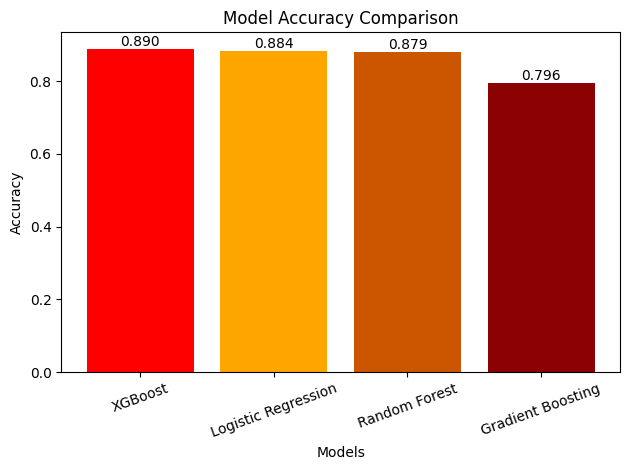

In [72]:
import matplotlib.pyplot as plt

# Data
models = ["Logistic Regression", "Random Forest", "XGBoost", "Gradient Boosting"]
accuracies = [0.883777507464337, 0.8793541966161672, 0.8900807254229791, 0.796195952670574]

# Sort by accuracy (descending)
models, accuracies = zip(*sorted(zip(models, accuracies), key=lambda x: x[1], reverse=True))

# Custom colors (red → orange → burnt orange → dark red)
colors = ["red", "orange", "#cc5500", "#8b0000"]

plt.figure()

bars = plt.bar(models, accuracies, color=colors)

# Add value labels on top
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.3f}",
        ha='center',
        va='bottom'
    )

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

# **KEY challenge**
The major issue in the Portuguese Bank dataset was class imbalance. Since the class weights were biased, I used threshold adjustment and imbalance-handling techniques to ensure the model learned effectively.

The dataset contained many object-type categorical variables. I handled this by converting binary categories to boolean and applying one-hot encoding to the rest, which improved the model’s ability to learn.

Default probability threshold (0.5) did not give the best recall, so threshold tuning was necessary.